# Laboratorio 1 — Exploración, preparación y regresión lineal

**Curso:** ISIS-2611 — Aprendizaje de Máquina  
**Caso:** AlpesPlanck  
**Integrantes:**  
- Daniel Vergara 202320392
- Julian Pinto

---

## Objetivo

Construir y evaluar modelos de regresión lineal para predecir la **temperatura máxima diaria**, identificar las variables meteorológicas que más aportan a la predicción y analizar posibles sesgos del proceso.


## Estructura del repositorio

```text
L1/
├── Laboratorio_1.ipynb
├── Laboratorio_1.html
├── README.md
├── data/
│   ├── Datos Lab 1.csv
│   ├── Datos Test Lab 1.csv
│   └── Diccionario de datos.xlsx
└── resultados/
    └── Datos Test Lab 1_predicciones.csv
```


# 0. Configuración e importación de librerías

En esta sección se importan las librerías necesarias para:
- manipulación de datos,
- visualización,
- preparación,
- construcción de pipelines,
- regresión lineal,
- evaluación del modelo.

Agregar otras librerías únicamente si se necesitan y explicar para qué se usan.


In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Separación de datos
from sklearn.model_selection import train_test_split

# Preparación
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modelo
from sklearn.linear_model import LinearRegression

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Utilidades
from pathlib import Path

pd.set_option("display.max_columns", None)


In [2]:
# Rutas relativas del proyecto
DATA_DIR = Path("data")
RESULTS_DIR = Path("resultados")
RESULTS_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "Datos Lab 1.csv"
FINAL_TEST_PATH = DATA_DIR / "Datos Test Lab 1.csv"
DICTIONARY_PATH = DATA_DIR / "Diccionario de datos.xlsx"

print("Datos de entrenamiento:", TRAIN_PATH)
print("Datos finales sin etiqueta:", FINAL_TEST_PATH)


Datos de entrenamiento: data\Datos Lab 1.csv
Datos finales sin etiqueta: data\Datos Test Lab 1.csv


# 1. Entendimiento del problema y de los datos

## 1.1 Contexto


El Instituto AlpesPlanck registra variables meteorológicas en su estación de Jena, Alemania. A partir de estos datos se busca construir un modelo que permita predecir la temperatura máxima del día siguiente e identificar cuáles variables meteorológicas aportan más a esta predicción.

El problema corresponde a una tarea de **aprendizaje supervisado**, ya que el conjunto de entrenamiento contiene una variable objetivo conocida. Como esta variable es numérica continua, la tarea corresponde específicamente a un problema de **regresión**.

La variable objetivo del conjunto de datos es `temp_max_manana`, que representa la temperatura máxima que se quiere predecir para el día siguiente.

Cada registro representa la información meteorológica agregada de un día. Entre las variables disponibles se encuentran medidas relacionadas con presión atmosférica, humedad, viento, ráfagas, dirección del viento y variables temporales como año, mes y día del año.


## 1.2 Diccionario de datos

Revisar primero el archivo `Diccionario de datos.xlsx`.

**Aquí deben escribir un resumen de las variables relevantes y señalar cuál será la variable objetivo.**


In [4]:
# Cargar diccionario de datos
diccionario = pd.read_excel(DICTIONARY_PATH)
diccionario


,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


### Análisis del diccionario

El diccionario de datos nos permite conocer el significado, tipo y unidad de las variables antes de hacer  el análisis. Este paso es importante para diferenciar el tipo técnico que Pandas detecta en cada columna del significado real de la variable.

A partir del diccionario y del contexto del laboratorio identificamos `temp_max_manana` como la variable objetivo. Las demás columnas corresponden a otras variables que describen las condiciones meteorológicas y características temporales de cada día.


# 2. Carga de datos


In [9]:
# Cargar datos de entrenamiento
data = pd.read_csv(TRAIN_PATH)

data.head()




,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


In [10]:
print("Número de registros:", data.shape[0])
print("Número de variables:", data.shape[1])

print("\nColumnas:")
print(data.columns.tolist())

Número de registros: 2576
Número de variables: 27

Columnas:
['fecha', 'presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio', 'estacion_anio', 'mes', 'sector_viento', 'temp_max_manana']


In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

## 2.1 Observaciones iniciales

A partir de la estructura del conjunto de datos se observa que cada fila corresponde a un día y contiene diferentes medidas meteorológicas agregadas.

El conjunto incluye variables numéricas relacionadas con presión, humedad, viento y ráfagas; variables temporales como `fecha`, `anio`, `dia_del_anio` y `mes`. Variables categóricas como `estacion_anio` y `sector_viento` y la variable objetivo `temp_max_manana`.

En esta etapa todavía no se realizan correcciones. Primero se identificarán formalmente los posibles problemas de calidad durante el análisis exploratorio.


In [12]:
# Estadísticas descriptivas
data.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,2504,2486,2009-01-22,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presion_media,2501.0,NaN,NaN,NaN,1010.494271,435.334494,948.996,984.2878,989.4528,994.469,9939.918
presion_min,2502.0,NaN,NaN,NaN,986.684409,8.927138,913.6,981.371333,987.07,992.5675,1012.320198
presion_max,2512.0,NaN,NaN,NaN,991.704244,7.726906,951.94,987.07,991.935,996.7825,1013.94
presion_desv,2496.0,NaN,NaN,NaN,1.752041,1.215931,0.2269,0.89905,1.44455,2.2548,12.3975
humedad_media,2502.0,NaN,NaN,NaN,52.413586,35.975384,0.004663,0.86906,68.5581,80.5626,100.0
humedad_min,2496.0,NaN,NaN,NaN,45.094067,30.196163,0.2377,1.01179,49.67,67.665,103.311405
humedad_max,2490.0,NaN,NaN,NaN,90.236582,10.647237,27.02,88.025,93.3,96.6,100.0
humedad_desv,2515.0,NaN,NaN,NaN,10.606821,5.481338,0.0,6.0821,10.1998,14.7222,26.3416
viento_media,2490.0,NaN,NaN,NaN,3.814103,3.307402,0.0,1.65535,2.4634,4.880505,24.7536


# 3. Exploración de datos (EDA)

1. Tipos de variables
2. Comportamiento general de las variables
3. Completitud
4.  Unicidad
5.  Consistencia
6.  Validez
7. Relación entre variables
8. Conclusiones del EDA


## 3.1 Tipos de variables


In [13]:
data.dtypes


fecha                    str
presion_media        float64
presion_min          float64
presion_max          float64
presion_desv         float64
humedad_media        float64
humedad_min          float64
humedad_max          float64
humedad_desv         float64
viento_media         float64
viento_min           float64
viento_max           float64
viento_desv          float64
rafaga_media         float64
rafaga_min           float64
rafaga_max           float64
rafaga_desv          float64
viento_norte         float64
viento_este          float64
direccion_viento     float64
registros_del_dia    float64
anio                 float64
dia_del_anio         float64
estacion_anio            str
mes                      str
sector_viento            str
temp_max_manana      float64
dtype: object

In [14]:

columnas_numericas = data.select_dtypes(include=np.number).columns.tolist()
columnas_no_numericas = data.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables no numéricas:")
print(columnas_no_numericas)

Variables numéricas:
['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio', 'temp_max_manana']

Variables no numéricas:
['fecha', 'estacion_anio', 'mes', 'sector_viento']


### Análisis de los tipos de variables

Los tipos técnicos detectados por Pandas deben compararse con el significado de las variables descrito en el diccionario de datos.

Por ahora no se realizarán transformaciones solamente se identifican estas características para utilizarlas después durante la preparación de los datos.

## 3.2 Comportamiento de las variables
### Variables numéricas



In [15]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
presion_media,2501.0,1010.494271,435.334494,948.996000,984.287800,989.452800,994.469000,9939.918000
presion_min,2502.0,986.684409,8.927138,913.600000,981.371333,987.070000,992.567500,1012.320198
presion_max,2512.0,991.704244,7.726906,951.940000,987.070000,991.935000,996.782500,1013.940000
presion_desv,2496.0,1.752041,1.215931,0.226900,0.899050,1.444550,2.254800,12.397500
humedad_media,2502.0,52.413586,35.975384,0.004663,0.869060,68.558100,80.562600,100.000000
humedad_min,2496.0,45.094067,30.196163,0.237700,1.011790,49.670000,67.665000,103.311405
humedad_max,2490.0,90.236582,10.647237,27.020000,88.025000,93.300000,96.600000,100.000000
humedad_desv,2515.0,10.606821,5.481338,0.000000,6.082100,10.199800,14.722200,26.341600
viento_media,2490.0,3.814103,3.307402,0.000000,1.655350,2.463400,4.880505,24.753600
viento_min,2485.0,1.417799,3.960650,0.000000,0.230000,0.440000,0.960000,45.184956


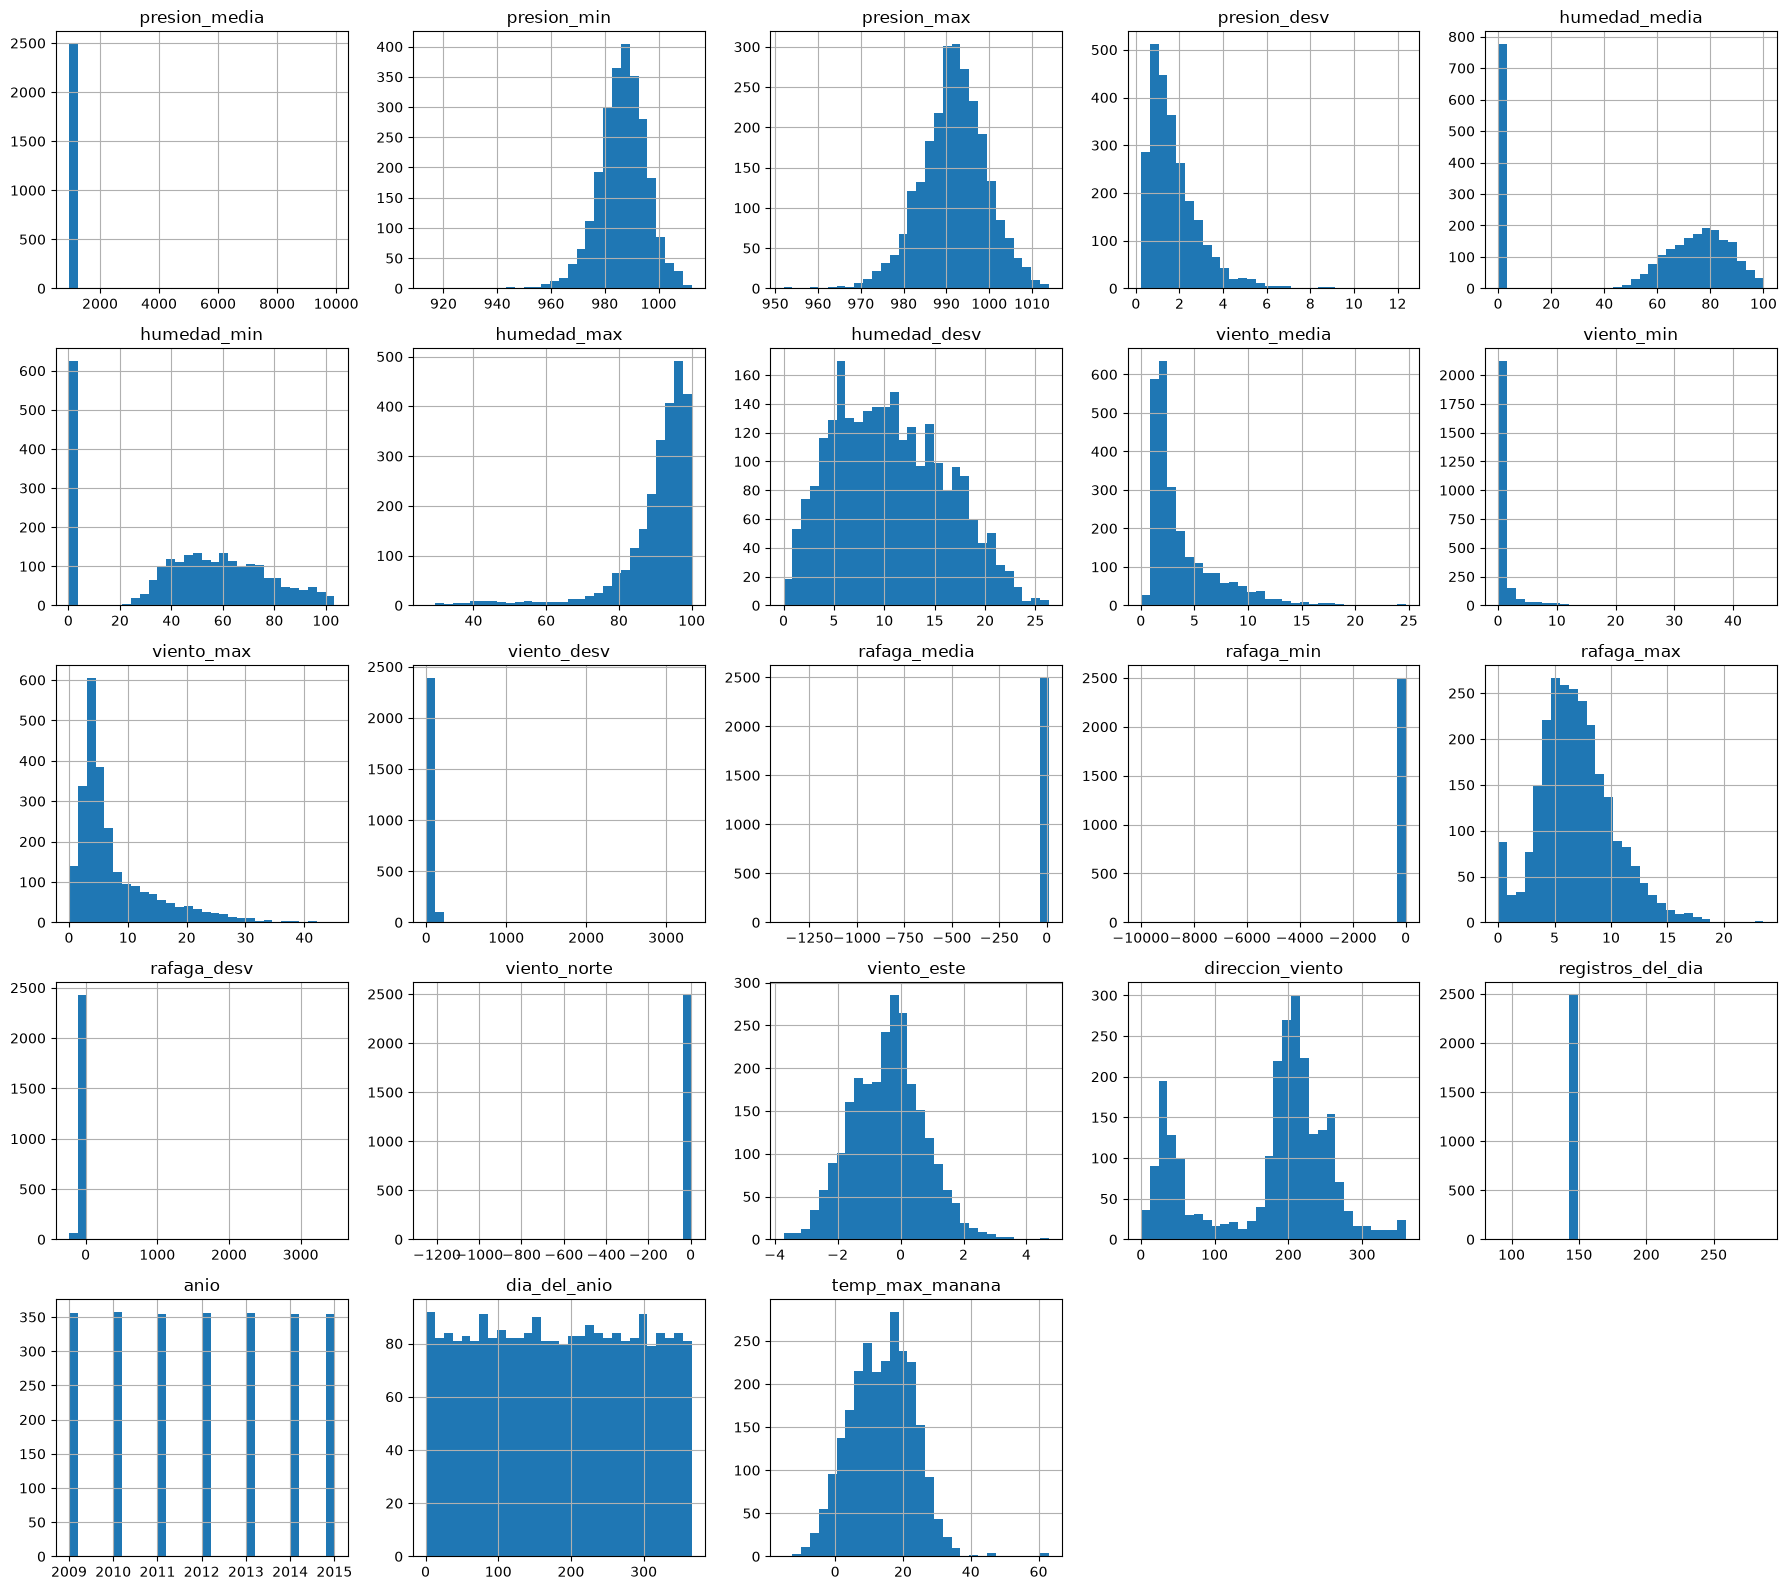

In [16]:
data[columnas_numericas].hist(
    figsize=(18, 16),
    bins=30
)

plt.tight_layout()
plt.show()

### Variables categóricas

In [17]:
for columna in columnas_no_numericas:
    print(f"\n--- {columna} ---")
    print(data[columna].value_counts(dropna=False))


--- fecha ---
fecha
NaN           72
2009-01-22     2
2009-03-05     2
2009-05-02     2
2009-12-08     2
              ..
2015-12-28     1
2015-12-29     1
2015-12-30     1
2015-12-31     1
2014-12-05     1
Name: count, Length: 2487, dtype: int64

--- estacion_anio ---
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO          

## 3.3 Completitud


In [18]:
# Cantidad de datos faltantes por variable
data.isnull().sum().sort_values(ascending=False)


temp_max_manana      95
viento_min           91
estacion_anio        88
mes                  88
anio                 86
humedad_max          86
viento_media         86
viento_max           81
humedad_min          80
viento_norte         80
presion_desv         80
rafaga_desv          79
direccion_viento     79
rafaga_media         78
registros_del_dia    77
presion_media        75
presion_min          74
humedad_media        74
rafaga_max           73
rafaga_min           72
viento_desv          72
fecha                72
sector_viento        71
dia_del_anio         68
presion_max          64
viento_este          64
humedad_desv         61
dtype: int64

In [19]:
# Proporción de datos faltantes por variable
porcentaje_faltantes = (
    data.isnull().sum() / data.shape[0] * 100
).sort_values(ascending=False)

porcentaje_faltantes

temp_max_manana      3.687888
viento_min           3.532609
estacion_anio        3.416149
mes                  3.416149
anio                 3.338509
humedad_max          3.338509
viento_media         3.338509
viento_max           3.144410
humedad_min          3.105590
viento_norte         3.105590
presion_desv         3.105590
rafaga_desv          3.066770
direccion_viento     3.066770
rafaga_media         3.027950
registros_del_dia    2.989130
presion_media        2.911491
presion_min          2.872671
humedad_media        2.872671
rafaga_max           2.833851
rafaga_min           2.795031
viento_desv          2.795031
fecha                2.795031
sector_viento        2.756211
dia_del_anio         2.639752
presion_max          2.484472
viento_este          2.484472
humedad_desv         2.368012
dtype: float64

### Análisis de completitud

Se identificaron valores faltantes en algunas de las variables del conjunto de datos.

Las variables con mayor porcentaje de datos faltantes fueron `temp_max_manana`, `viento_min` y `estacion_anio `, con aproximadamente `3.68%`, `3.53%` y `3.41%` respectivamente.

## 3.4 Unicidad


In [21]:
# Número de filas completamente duplicadas
duplicados = data.duplicated(keep=False).sum()

print("Número de registros involucrados en duplicados:", duplicados)

Número de registros involucrados en duplicados: 8


In [23]:
# Ver las filas duplicadas
data[data.duplicated(keep=False)]

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,1.440,26.532,178.43,4.2533,0.88,10.13,-122.650,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
1412,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,0.792,9.576,48.94,1.8189,0.40,3.80,-32.660,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
1499,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,0.648,10.656,50.07,1.5029,0.52,5.01,-36.085,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
1570,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,7.380,23.544,77.24,7.1450,3.72,9.41,-54.325,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2556,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,7.380,23.544,77.24,7.1450,3.72,9.41,-54.325,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2559,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,0.792,9.576,48.94,1.8189,0.40,3.80,-32.660,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,1.440,26.532,178.43,4.2533,0.88,10.13,-122.650,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
2565,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,0.648,10.656,50.07,1.5029,0.52,5.01,-36.085,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600


## 3.5 Consistencia  


In [26]:
columnas_categoricas = [
    col for col in columnas_no_numericas
    if col != "fecha"
]

for columna in columnas_categoricas:
    print(f"\nVariable: {columna}")
    print(data[columna].value_counts(dropna=False))


Variable: estacion_anio
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

Variable: mes
mes
May           127
August        125
July          123
January       120
March         118
             .

### Análisis de consistencia

La consistencia busca verificar que los valores que representan un mismo concepto se encuentren registrados de la misma manera.

Para las variables categóricas se revisaron sus categorías y frecuencias mediante `value_counts()`. Esto permite detectar posibles diferencias de formato, como el uso inconsistente de mayúsculas y minúsculas o valores que podrían corresponder a categorías incorrectas.


## 3.6 Validez

In [27]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
presion_media,2501.0,1010.494271,435.334494,948.996000,984.287800,989.452800,994.469000,9939.918000
presion_min,2502.0,986.684409,8.927138,913.600000,981.371333,987.070000,992.567500,1012.320198
presion_max,2512.0,991.704244,7.726906,951.940000,987.070000,991.935000,996.782500,1013.940000
presion_desv,2496.0,1.752041,1.215931,0.226900,0.899050,1.444550,2.254800,12.397500
humedad_media,2502.0,52.413586,35.975384,0.004663,0.869060,68.558100,80.562600,100.000000
humedad_min,2496.0,45.094067,30.196163,0.237700,1.011790,49.670000,67.665000,103.311405
humedad_max,2490.0,90.236582,10.647237,27.020000,88.025000,93.300000,96.600000,100.000000
humedad_desv,2515.0,10.606821,5.481338,0.000000,6.082100,10.199800,14.722200,26.341600
viento_media,2490.0,3.814103,3.307402,0.000000,1.655350,2.463400,4.880505,24.753600
viento_min,2485.0,1.417799,3.960650,0.000000,0.230000,0.440000,0.960000,45.184956


In [28]:
columnas_humedad = [
    "humedad_media",
    "humedad_min",
    "humedad_max",
    "humedad_desv"
]

data[columnas_humedad].describe().T

,count,mean,std,min,25%,50%,75%,max
humedad_media,2502.0,52.413586,35.975384,0.004663,0.86906,68.5581,80.5626,100.000000
humedad_min,2496.0,45.094067,30.196163,0.237700,1.01179,49.6700,67.6650,103.311405
humedad_max,2490.0,90.236582,10.647237,27.020000,88.02500,93.3000,96.6000,100.000000
humedad_desv,2515.0,10.606821,5.481338,0.000000,6.08210,10.1998,14.7222,26.341600


### 3.6.1 Valores atípicos

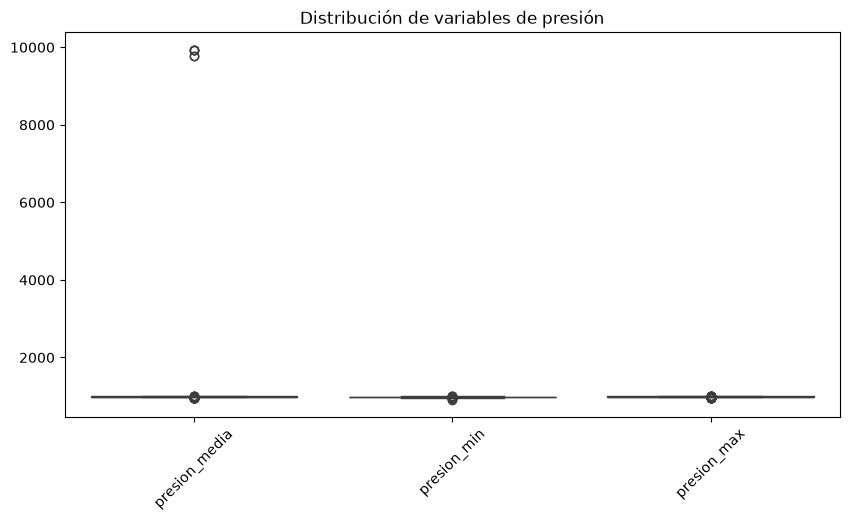

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[["presion_media", "presion_min", "presion_max"]])
plt.title("Distribución de variables de presión")
plt.xticks(rotation=45)
plt.show()

## 3.5 Distribución de variables numéricas


In [ ]:
# Seleccionar variables numéricas
numeric_cols = data.select_dtypes(include=np.number).columns

# Histogramas
data[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()


**Análisis:**  
Describir distribuciones llamativas, asimetrías, concentraciones y posibles valores atípicos.


## 3.6 Valores atípicos

Usar boxplots u otras técnicas cuando sean pertinentes. No eliminar un valor atípico únicamente porque sea extremo: primero determinar si representa un error o una observación válida.


In [ ]:
# Ejemplo: boxplot para una variable
# sns.boxplot(x=data["NOMBRE_VARIABLE"])
# plt.show()


## 3.7 Correlaciones entre variables numéricas


In [ ]:
corr = data[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()


**Análisis:**  
- ¿Qué variables parecen estar más relacionadas con la variable objetivo?
- ¿Existen variables muy correlacionadas entre sí?
- ¿Podría existir redundancia o multicolinealidad?


# 4. Preparación de datos

Las transformaciones deben salir de los problemas encontrados durante el EDA.

Ejemplos:
- corregir tipos,
- eliminar duplicados justificados,
- imputar valores faltantes,
- transformar variables,
- crear nuevas características,
- seleccionar variables,
- codificar variables categóricas,
- escalar cuando corresponda.

> Evitar modificar el conjunto completo antes de la separación entrenamiento/prueba si esa transformación aprende parámetros de los datos. Para esos casos se deben usar **pipelines**.


## 4.1 Definición de la variable objetivo

Reemplazar `TARGET` por el nombre exacto de la columna que representa la temperatura máxima.


In [ ]:
TARGET = "REEMPLAZAR_CON_VARIABLE_OBJETIVO"

# X = variables predictoras
# y = variable objetivo
# X = data.drop(columns=[TARGET])
# y = data[TARGET]


## 4.2 Separación entrenamiento / prueba

El laboratorio exige:
- `test_size = 0.25`
- `random_state = 42`


In [ ]:
# Descomentar después de definir TARGET

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.25,
#     random_state=42
# )

# print("X_train:", X_train.shape)
# print("X_test:", X_test.shape)


# 5. Modelo 1 — Regresión lineal base

Construir una primera estrategia de preparación y justificarla.

### Hipótesis / estrategia del modelo 1
Escribir aquí:
- qué variables se usarán,
- qué tratamiento de faltantes se aplicará,
- si se escalarán variables,
- qué transformaciones se incluirán,
- por qué esta estrategia constituye una buena línea base.


In [ ]:
# EJEMPLO DE ESTRUCTURA DEL PIPELINE
# Ajustar las listas una vez realizado el EDA.

# numeric_features_m1 = [...]
# categorical_features_m1 = [...]

# numeric_transformer_m1 = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])

# categorical_transformer_m1 = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore"))
# ])

# preprocessor_m1 = ColumnTransformer(
#     transformers=[
#         ("num", numeric_transformer_m1, numeric_features_m1),
#         ("cat", categorical_transformer_m1, categorical_features_m1)
#     ]
# )

# model_1 = Pipeline(steps=[
#     ("preprocessor", preprocessor_m1),
#     ("regressor", LinearRegression())
# ])


In [ ]:
# Entrenar modelo 1
# model_1.fit(X_train, y_train)

# pred_1 = model_1.predict(X_test)


## 5.1 Evaluación del modelo 1


In [ ]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# metrics_1 = regression_metrics(y_test, pred_1)
# metrics_1


**Interpretación del modelo 1:**  
Explicar qué significan los valores obtenidos y cuáles parecen ser las principales limitaciones del modelo.


# 6. Modelo 2 — Regresión lineal con una preparación diferente

El laboratorio exige al menos dos modelos de regresión lineal con **estrategias de preparación/ingeniería de características diferentes y justificadas**.

### Hipótesis / estrategia del modelo 2

Por ejemplo, aquí podrían probar:
- otra selección de variables,
- nuevas características,
- tratamiento distinto de atípicos,
- transformación de variables,
- eliminación de variables redundantes,
- otra estrategia de imputación.

La decisión concreta debe salir del EDA.


In [ ]:
# Construir pipeline del modelo 2

# model_2 = Pipeline(steps=[
#     ...
# ])


In [ ]:
# Entrenar y evaluar modelo 2

# model_2.fit(X_train, y_train)
# pred_2 = model_2.predict(X_test)
# metrics_2 = regression_metrics(y_test, pred_2)
# metrics_2


# 7. Comparación de modelos

Construir la tabla final con los dos mejores modelos analizados.


In [ ]:
# Ejemplo:
# comparacion = pd.DataFrame([
#     {"Modelo": "Modelo 1", **metrics_1},
#     {"Modelo": "Modelo 2", **metrics_2}
# ])

# comparacion.sort_values("RMSE")


## Selección del mejor modelo

**Modelo seleccionado:** ...

**Justificación:**  
Comparar principalmente RMSE, pero interpretar también MAE y R². Explicar por qué se escoge el modelo final y si la diferencia respecto al otro modelo es relevante.


# 8. Evaluación cualitativa e interpretación

## 8.1 Coeficientes del mejor modelo

Obtener los nombres de las características después del pipeline y asociarlos con los coeficientes de la regresión.


In [ ]:
# BASE PARA EXTRAER COEFICIENTES
# Ajustar al nombre del mejor pipeline.

# best_model = model_2
# preprocessor = best_model.named_steps["preprocessor"]
# regressor = best_model.named_steps["regressor"]

# feature_names = preprocessor.get_feature_names_out()

# coeficientes = (
#     pd.DataFrame({
#         "variable": feature_names,
#         "coeficiente": regressor.coef_
#     })
#     .assign(importancia_abs=lambda df: df["coeficiente"].abs())
#     .sort_values("importancia_abs", ascending=False)
# )

# coeficientes


### Interpretación

Responder:
- ¿Cuáles variables tienen los coeficientes de mayor magnitud?
- ¿Qué significa el signo positivo o negativo?
- ¿Qué interpretación puede darse en el contexto meteorológico?
- ¿La escala de las variables permite comparar directamente los coeficientes?


# 9. Verificación de supuestos de regresión lineal

Antes de hacer interpretaciones fuertes de los coeficientes, revisar los supuestos vistos en clase.

Incluir al menos los análisis correspondientes indicados en la práctica de verificación de supuestos.

### Posibles apartados
- linealidad,
- comportamiento de residuos,
- homocedasticidad,
- normalidad de residuos,
- independencia,
- multicolinealidad.

Agregar gráficos/pruebas y una conclusión para cada supuesto.


In [ ]:
# Residuos del mejor modelo
# best_pred = best_model.predict(X_test)
# residuals = y_test - best_pred

# Ejemplo: residuos vs predicción
# plt.scatter(best_pred, residuals, alpha=0.6)
# plt.axhline(0, linestyle="--")
# plt.xlabel("Valores predichos")
# plt.ylabel("Residuos")
# plt.title("Residuos vs valores predichos")
# plt.show()


# 10. Análisis de resultados

Responder explícitamente las preguntas solicitadas en el laboratorio.

## 10.1 ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

**Respuesta:**  
...

## 10.2 ¿Cuál modelo ofrece el mejor rendimiento sobre test? ¿Cómo se interpretan RMSE, MAE y R²?

**Respuesta:**  
...

## 10.3 ¿Cuáles variables fueron seleccionadas? ¿Qué interpretación tienen en el problema?

**Respuesta:**  
...

## 10.4 Representación matemática de la regresión lineal

Escribir el modelo de forma general:

\[
\hat{y}=\beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p
\]

Luego reemplazarlo por la ecuación correspondiente al modelo obtenido.

**Método utilizado para estimar los parámetros:**  
...


# 11. Sesgos posibles

Describir **dos tipos de sesgo** que podrían afectar este proyecto y explicar específicamente por qué podrían aparecer con estos datos.

### Sesgo 1: ...
**Explicación:** ...

### Sesgo 2: ...
**Explicación:** ...


# 12. Predicciones sobre el conjunto final sin etiqueta

Una vez seleccionado y validado el mejor modelo:
1. cargar `Datos Test Lab 1.csv`,
2. aplicar el mismo pipeline,
3. generar la predicción,
4. agregar la columna solicitada,
5. exportar el CSV conservando las demás columnas.


In [ ]:
final_test = pd.read_csv(FINAL_TEST_PATH)

print(final_test.shape)
final_test.head()


In [ ]:
# Generar predicciones finales
# final_predictions = best_model.predict(final_test)

# IMPORTANTE:
# reemplazar el nombre de la columna por el nombre EXACTO solicitado por el laboratorio.
# final_output = final_test.copy()
# final_output["NOMBRE_COLUMNA_PREDICCION"] = final_predictions

# OUTPUT_PATH = RESULTS_DIR / "Datos Test Lab 1_predicciones.csv"
# final_output.to_csv(OUTPUT_PATH, index=False)

# print("Archivo guardado en:", OUTPUT_PATH)


# 13. Conclusiones

Redactar de forma corta y concreta:

1. qué tan bien funcionó el modelo,
2. qué estrategia mejoró más los resultados,
3. cuáles variables fueron más relevantes,
4. qué limitaciones tiene el análisis,
5. cómo podría usarse este conocimiento en el contexto de AlpesPlanck.


# 14. Uso de herramientas de IA generativa

Esta sección es obligatoria si se utilizó IA.

## Declaración del uso

**Herramienta:** ...  
**Tipo de uso:** ayuda conceptual / generación inicial de código / depuración / redacción / etc.

## Prompts principales utilizados

1. `...`
2. `...`
3. `...`

## Análisis crítico del resultado

Responder al menos dos:
- ¿Qué partes generadas fueron correctas y útiles?
- ¿Qué errores, imprecisiones o limitaciones se identificaron?
- ¿Qué decisiones técnicas fueron modificadas y por qué?
- ¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta?

**Respuesta:**  
...

## Aportes propios

Explicar qué fue desarrollado, modificado y decidido por los integrantes del grupo.

**Respuesta:**  
...


# 15. Checklist antes de entregar

- [ ] El notebook ejecuta de principio a fin sin errores.
- [ ] Todas las celdas tienen sus resultados visibles.
- [ ] El EDA contiene conclusiones y no solo gráficos.
- [ ] Las decisiones de preparación están justificadas.
- [ ] Se construyeron al menos dos regresiones lineales con estrategias diferentes.
- [ ] Se usaron pipelines.
- [ ] La separación usa `test_size=0.25` y `random_state=42`.
- [ ] Se comparan RMSE, MAE y R².
- [ ] Se presenta una tabla de coeficientes/importancia.
- [ ] Se verifican los supuestos de regresión lineal.
- [ ] Se responden todas las preguntas de análisis.
- [ ] Se discuten dos posibles sesgos.
- [ ] Se generan las predicciones finales.
- [ ] Se exporta el CSV requerido.
- [ ] Se documenta el uso de IA.
- [ ] Se exporta también el notebook a `.html`.
